In [11]:
import math
import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm
from pygam import LinearGAM, s
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")

mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["font.size"] = 12
mpl.rcParams["axes.titlesize"] = 12
mpl.rcParams["axes.labelsize"] = 12
mpl.rcParams["xtick.labelsize"] = 12
mpl.rcParams["ytick.labelsize"] = 12
mpl.rcParams["legend.fontsize"] = 12
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"

df = pd.read_excel("Q-RMR Data (Including Q).xlsx", sheet_name=0)
df.columns = [str(c).strip() for c in df.columns]

needed_cols = ["RQD", "Jn", "Jr", "Ja", "Jw", "SRF", "Q", "RMR"]
df = df[needed_cols].apply(pd.to_numeric, errors="coerce")

data = df[(df["Q"] > 0) & np.isfinite(df["Q"]) & np.isfinite(df["RMR"])].dropna().copy()

eps = 1e-9
data["lnQ"] = np.log(data["Q"].clip(lower=eps))
data["ln_RQD_Jn"] = np.log(data["RQD"].clip(lower=eps) / data["Jn"].clip(lower=eps))
data["ln_Jr_Ja"] = np.log(data["Jr"].clip(lower=eps) / data["Ja"].clip(lower=eps))
data["ln_Jw_SRF"] = np.log(data["Jw"].clip(lower=eps) / data["SRF"].clip(lower=eps))

def metrics(y, yhat):
    r2 = r2_score(y, yhat)
    rmse = math.sqrt(mean_squared_error(y, yhat))
    mae = mean_absolute_error(y, yhat)
    return round(r2, 4), round(rmse, 4), round(mae, 4)

perf_rows = []

X_lin = sm.add_constant(data[["lnQ"]])
model_lin = sm.OLS(data["RMR"], X_lin, missing="drop").fit()
pred_lin = model_lin.predict(X_lin)
r2, rmse, mae = metrics(data["RMR"], pred_lin)
perf_rows.append(["Linear (RMR ~ lnQ)", r2, rmse, mae])

X_aug = sm.add_constant(data[["ln_RQD_Jn", "ln_Jr_Ja", "ln_Jw_SRF"]])
model_aug = sm.OLS(data["RMR"], X_aug, missing="drop").fit()
pred_aug = model_aug.predict(X_aug)
r2, rmse, mae = metrics(data["RMR"], pred_aug)
perf_rows.append(["Extended log-feature model", r2, rmse, mae])

gam = LinearGAM(s(0)).fit(data[["lnQ"]].values, data["RMR"].values)
x_grid_gam = np.linspace(data["lnQ"].min(), data["lnQ"].max(), 200)
X_gam = x_grid_gam.reshape(-1, 1)
pred_gam_curve = gam.predict(X_gam)
pred_gam = gam.predict(data[["lnQ"]].values)
r2, rmse, mae = metrics(data["RMR"].values, pred_gam)
perf_rows.append(["GAM: RMR ~ s(lnQ)", r2, rmse, mae])

k1 = np.log(1.0)
k2 = np.log(10.0)
data["h1"] = np.maximum(0.0, data["lnQ"] - k1)
data["h2"] = np.maximum(0.0, data["lnQ"] - k2)

X_piece = sm.add_constant(data[["lnQ", "h1", "h2"]])
model_piece = sm.OLS(data["RMR"], X_piece, missing="drop").fit()
pred_piece = model_piece.predict(X_piece)
r2, rmse, mae = metrics(data["RMR"], pred_piece)
perf_rows.append(["Piecewise (hinge at Q=1, 10)", r2, rmse, mae])

perf = pd.DataFrame(perf_rows, columns=["Model", "R2", "RMSE", "MAE"])

print("\n[Linear] RMR ~ lnQ")
print(model_lin.summary())

print("\n[Extended] RMR ~ ln(RQD/Jn) + ln(Jr/Ja) + ln(Jw/SRF)")
print(model_aug.summary())

print("\n[GAM] RMR ~ s(lnQ)")
print(f"R2={metrics(data['RMR'].values, pred_gam)[0]:.4f}, RMSE={metrics(data['RMR'].values, pred_gam)[1]:.4f}, MAE={metrics(data['RMR'].values, pred_gam)[2]:.4f}")

print("\n[Piecewise] RMR ~ lnQ + max(0, lnQ - ln1) + max(0, lnQ - ln10)")
print(model_piece.summary())

print("\n=== Baseline Performance ===")
display(perf)


[Linear] RMR ~ lnQ
                            OLS Regression Results                            
Dep. Variable:                    RMR   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                     1556.
Date:                Wed, 15 Apr 2026   Prob (F-statistic):          1.66e-147
Time:                        10:25:58   Log-Likelihood:                -1162.5
No. Observations:                 448   AIC:                             2329.
Df Residuals:                     446   BIC:                             2337.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         46.3104      0.180

,Model,R2,RMSE,MAE
0,Linear (RMR ~ lnQ),0.7772,3.2408,1.7713
1,Extended log-feature model,0.7144,3.6695,1.7993
2,GAM: RMR ~ s(lnQ),0.8868,2.3102,1.0874
3,"Piecewise (hinge at Q=1, 10)",0.8731,2.4454,1.1708


In [21]:
import numpy as np
import matplotlib.pyplot as plt

def parity_plot(y, yhat, title):
    y = np.asarray(y)
    yhat = np.asarray(yhat)

    r2 = r2_score(y, yhat)

    fig, ax = plt.subplots(figsize=(4, 3.5))

    ax.scatter(
        y, yhat,
        s=35,
        alpha=0.8,
        color="#87CEFA",
        edgecolors="grey"
    )

    ax.plot([0, 100], [0, 100], lw=1, color="black")

    ax.set_xlabel("Observed RMR")
    ax.set_ylabel("Predicted RMR")
    ax.set_title(title)

    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_xticks(np.arange(0, 101, 20))
    ax.set_yticks(np.arange(0, 101, 20))

    ax.grid(True, linestyle="--", alpha=0.5)
    ax.tick_params(direction="in")

    txt = f"R2={r2:.4f}"
    ax.text(
        0.03, 0.97, txt,
        transform=ax.transAxes,
        va="top", ha="left"
    )

    fig.tight_layout()
    plt.show()

def plot_partial_effect_linear(model, data, feature, all_feature_names, xlabel, title):
    f_series = data[feature].dropna()
    x_min = f_series.quantile(0.01)
    x_max = f_series.quantile(0.99)
    x_grid = np.linspace(x_min, x_max, 100)

    df_pred = pd.DataFrame({feature: x_grid})
    for f in all_feature_names:
        if f != feature:
            df_pred[f] = data[f].mean()

    X_pred = sm.add_constant(df_pred[all_feature_names], has_constant="add")
    exog_cols = model.model.exog_names
    X_pred = X_pred[exog_cols]

    y_pred = model.predict(X_pred)

    fig, ax = plt.subplots(figsize=(4, 3.5))

    mask = data[feature].between(x_min, x_max)
    ax.scatter(
        data.loc[mask, feature],
        data.loc[mask, "RMR"],
        s=35,
        alpha=0.8,
        color="#87CEFA",
        edgecolors="grey"
    )

    ax.plot(x_grid, y_pred, lw=2, color="#4682B4")

    ax.set_xlabel(xlabel)
    ax.set_ylabel("RMR")
    ax.set_title(title)

    ax.set_ylim(0, 100)
    ax.set_yticks(np.arange(0, 101, 20))

    ax.grid(True, linestyle="--", alpha=0.5)
    ax.tick_params(direction="in")

    fig.tight_layout()
    plt.show()

Bieniawski’s expression RMR = 9 lnQ + 44: R2 = 0.6630
Cameron-Clarke and Budavari’s formula RMR = 5 lnQ + 60.8: R2 = -3.1641


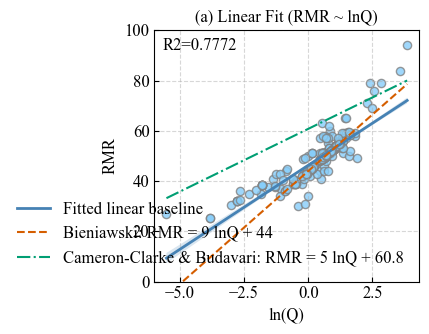

In [23]:
r2_lin, rmse_lin, mae_lin = metrics(data["RMR"], pred_lin)

yhat_bienia_data = 9.0 * data["lnQ"] + 44.0
r2_bienia, _, _ = metrics(data["RMR"], yhat_bienia_data)

yhat_ccb_data = 5.0 * data["lnQ"] + 60.8
r2_ccb, _, _ = metrics(data["RMR"], yhat_ccb_data)

print(f"Bieniawski’s expression RMR = 9 lnQ + 44: R2 = {r2_bienia:.4f}")
print(f"Cameron-Clarke and Budavari’s formula RMR = 5 lnQ + 60.8: R2 = {r2_ccb:.4f}")

fig, ax = plt.subplots(figsize=(4, 3.5))

ax.scatter(
    data["lnQ"], data["RMR"],
    s=35,
    alpha=0.8,
    color="#87CEFA",
    edgecolors="grey"
)

x_grid = np.linspace(data["lnQ"].min(), data["lnQ"].max(), 200)
X_new = sm.add_constant(x_grid)

pred_res = model_lin.get_prediction(X_new)
pred_df = pred_res.summary_frame(alpha=0.05)

y_hat = pred_df["mean"].values
ci_lower = pred_df["mean_ci_lower"].values
ci_upper = pred_df["mean_ci_upper"].values

ax.plot(
    x_grid,
    y_hat,
    lw=2,
    color="#4682B4",
    label="Fitted linear baseline"
)

ax.fill_between(
    x_grid,
    ci_lower,
    ci_upper,
    color="#4682B4",
    alpha=0.2,
    edgecolor="none"
)

y_bienia_grid = 9.0 * x_grid + 44.0
ax.plot(
    x_grid,
    y_bienia_grid,
    lw=1.5,
    linestyle="--",
    color="#D55E00",
    label="Bieniawski: RMR = 9 lnQ + 44"
)

y_ccb_grid = 5.0 * x_grid + 60.8
ax.plot(
    x_grid,
    y_ccb_grid,
    lw=1.5,
    linestyle="-.",
    color="#009E73",
    label="Cameron-Clarke & Budavari: RMR = 5 lnQ + 60.8"
)

ax.set_xlabel("ln(Q)")
ax.set_ylabel("RMR")
ax.set_title("(a) Linear Fit (RMR ~ lnQ)")
ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 20))
ax.grid(True, linestyle="--", alpha=0.5)
ax.tick_params(direction="in")

txt = f"R2={r2_lin:.4f}"
ax.text(
    0.03, 0.97, txt,
    transform=ax.transAxes,
    va="top", ha="left"
)

ax.legend(frameon=False, loc="lower right")

fig.tight_layout()
plt.show()

Linear regression baseline: R2 = 0.7772
Bieniawski’s expression (9 lnQ + 44): R2 = 0.6630
Cameron-Clarke & Budavari (5 lnQ + 60.8): R2 = -3.1641


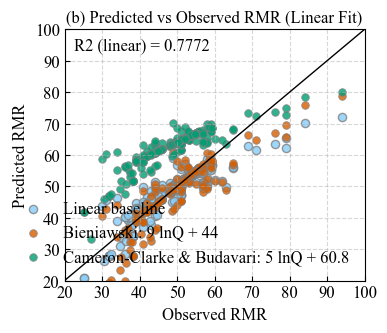

In [24]:
y_obs = data["RMR"].values
yhat_lin = np.asarray(pred_lin)
yhat_bienia = 9.0 * data["lnQ"].values + 44.0
yhat_ccb = 5.0 * data["lnQ"].values + 60.8

r2_lin = r2_score(y_obs, yhat_lin)
r2_bien = r2_score(y_obs, yhat_bienia)
r2_ccb = r2_score(y_obs, yhat_ccb)

print(f"Linear regression baseline: R2 = {r2_lin:.4f}")
print(f"Bieniawski’s expression (9 lnQ + 44): R2 = {r2_bien:.4f}")
print(f"Cameron-Clarke & Budavari (5 lnQ + 60.8): R2 = {r2_ccb:.4f}")

fig, ax = plt.subplots(figsize=(4, 3.5))

ax.scatter(
    y_obs, yhat_lin,
    s=35,
    alpha=0.8,
    color="#87CEFA",
    edgecolors="grey",
    label="Linear baseline"
)

ax.scatter(
    y_obs, yhat_bienia,
    s=30,
    alpha=0.8,
    color="#D55E00",
    edgecolors="grey",
    linewidths=0.6,
    label="Bieniawski: 9 lnQ + 44"
)

ax.scatter(
    y_obs, yhat_ccb,
    s=30,
    alpha=0.8,
    color="#009E73",
    edgecolors="grey",
    linewidths=0.6,
    label="Cameron-Clarke & Budavari: 5 lnQ + 60.8"
)

ax.plot([20, 100], [20, 100], lw=1, color="black")

ax.set_xlabel("Observed RMR")
ax.set_ylabel("Predicted RMR")
ax.set_title("(b) Predicted vs Observed RMR (Linear Fit)")

ax.set_xlim(20, 100)
ax.set_ylim(20, 100)
ax.set_xticks(np.arange(20, 101, 10))
ax.set_yticks(np.arange(20, 101, 10))

ax.grid(True, linestyle="--", alpha=0.5)
ax.tick_params(direction="in")

txt = f"R2 (linear) = {r2_lin:.4f}"
ax.text(
    0.03, 0.97, txt,
    transform=ax.transAxes,
    va="top", ha="left"
)

ax.legend(frameon=False, loc="lower right")

fig.tight_layout()
plt.show()

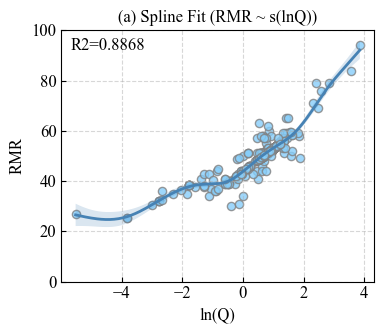

In [26]:
r2_gam, rmse_gam, mae_gam = metrics(data["RMR"], pred_gam)

fig, ax = plt.subplots(figsize=(4, 3.5))

ax.scatter(
    data["lnQ"], data["RMR"],
    s=35,
    alpha=0.8,
    color="#87CEFA",
    edgecolors="grey"
)

x_grid = x_grid_gam
X_gam_plot = X_gam

y_smooth = gam.predict(X_gam_plot)
ci = gam.confidence_intervals(X_gam_plot, width=0.95)
ci_lower = ci[:, 0]
ci_upper = ci[:, 1]

ax.plot(
    x_grid,
    y_smooth,
    lw=2,
    color="#4682B4"
)

ax.fill_between(
    x_grid,
    ci_lower,
    ci_upper,
    color="#4682B4",
    alpha=0.2,
    edgecolor="none"
)

ax.set_xlabel("ln(Q)")
ax.set_ylabel("RMR")
ax.set_title("(a) Spline Fit (RMR ~ s(lnQ))")
ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 20))
ax.grid(True, linestyle="--", alpha=0.5)
ax.tick_params(direction="in")

txt = f"R2={r2_gam:.4f}"
ax.text(
    0.03, 0.97, txt,
    transform=ax.transAxes,
    va="top", ha="left"
)

fig.tight_layout()
plt.show()

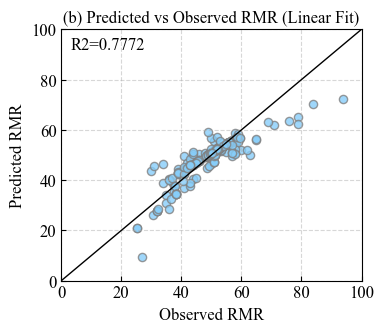

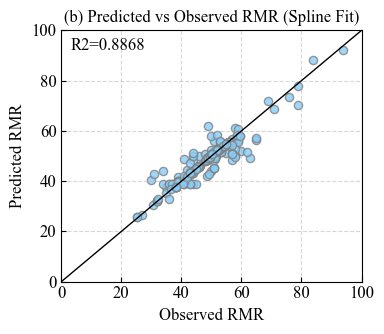

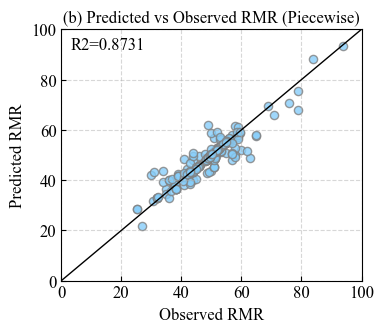

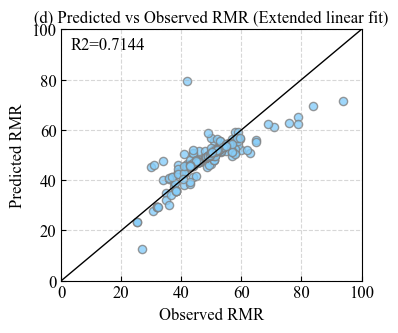

In [27]:
parity_plot(
    y=data["RMR"],
    yhat=pred_lin,
    title="(b) Predicted vs Observed RMR (Linear Fit)"
)

parity_plot(
    y=data["RMR"],
    yhat=pred_gam,
    title="(b) Predicted vs Observed RMR (Spline Fit)"
)

parity_plot(
    y=data["RMR"],
    yhat=pred_piece,
    title="(b) Predicted vs Observed RMR (Piecewise)"
)

parity_plot(
    y=data["RMR"],
    yhat=pred_aug,
    title="(d) Predicted vs Observed RMR (Extended linear fit)"
)

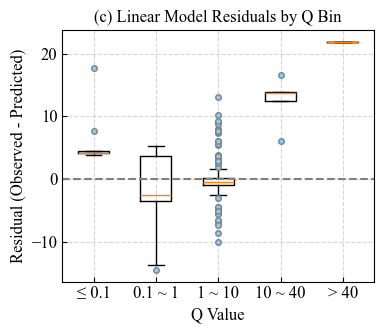

In [28]:
resid_lin = data["RMR"] - pred_lin

bins = [0, 0.1, 1, 10, 40, data["Q"].max()]
labels = ["≤ 0.1", "0.1 ~ 1", "1 ~ 10", "10 ~ 40", "> 40"]
data["Q_bin"] = pd.cut(data["Q"], bins=bins, labels=labels, include_lowest=True)

groups = [resid_lin[data["Q_bin"] == lab].dropna().values for lab in labels]

fig, ax = plt.subplots(figsize=(4, 3.5))

ax.boxplot(
    groups,
    labels=labels,
    showfliers=True,
    flierprops=dict(
        marker="o",
        markerfacecolor="#87CEFA",
        markeredgecolor="grey",
        markersize=4,
        linestyle="none"
    )
)

ax.axhline(0, color="gray", ls="--")
ax.set_xlabel("Q Value")
ax.set_ylabel("Residual (Observed - Predicted)")
ax.set_title("(c) Linear Model Residuals by Q Bin")
ax.grid(True, linestyle="--", alpha=0.5)
ax.tick_params(direction="in")

fig.tight_layout()
plt.show()

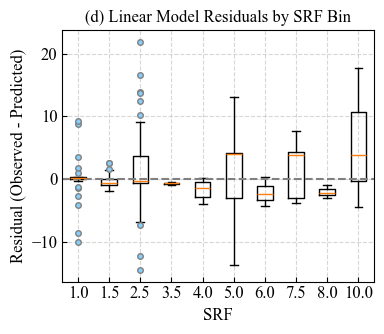

In [30]:
resid_lin = data["RMR"] - pred_lin

fig, ax = plt.subplots(figsize=(4, 3.5))
srf_vals = np.sort(data["SRF"].dropna().unique())
groups_srf = [resid_lin[data["SRF"] == v].dropna().values for v in srf_vals]

ax.boxplot(
    groups_srf,
    labels=[str(v) for v in srf_vals],
    showfliers=True,
    flierprops=dict(
        marker="o",
        markerfacecolor="#87CEFA",
        markeredgecolor="grey",
        markersize=4,
        linestyle="none"
    )
)

ax.axhline(0, color="gray", ls="--")
ax.set_xlabel("SRF")
ax.set_ylabel("Residual (Observed - Predicted)")
ax.set_title("(d) Linear Model Residuals by SRF Bin")
ax.grid(True, linestyle="--", alpha=0.5)
ax.tick_params(direction="in")

fig.tight_layout()
plt.show()

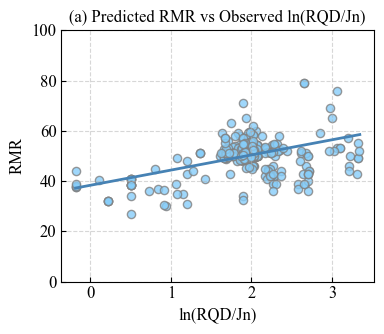

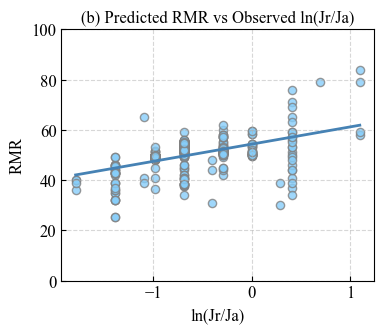

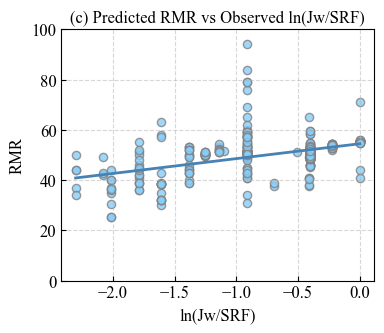

In [31]:
all_feats = ["ln_RQD_Jn", "ln_Jr_Ja", "ln_Jw_SRF"]

plot_partial_effect_linear(
    model=model_aug,
    data=data,
    feature="ln_RQD_Jn",
    all_feature_names=all_feats,
    xlabel="ln(RQD/Jn)",
    title="(a) Predicted RMR vs Observed ln(RQD/Jn)"
)

plot_partial_effect_linear(
    model=model_aug,
    data=data,
    feature="ln_Jr_Ja",
    all_feature_names=all_feats,
    xlabel="ln(Jr/Ja)",
    title="(b) Predicted RMR vs Observed ln(Jr/Ja)"
)

plot_partial_effect_linear(
    model=model_aug,
    data=data,
    feature="ln_Jw_SRF",
    all_feature_names=all_feats,
    xlabel="ln(Jw/SRF)",
    title="(c) Predicted RMR vs Observed ln(Jw/SRF)"
)

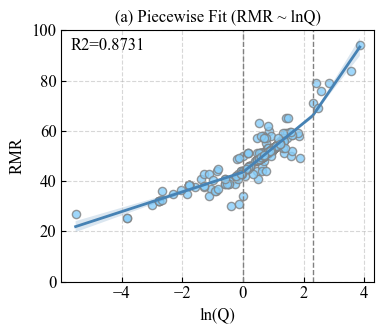

In [32]:
r2_piece, rmse_piece, mae_piece = metrics(data["RMR"], pred_piece)

fig, ax = plt.subplots(figsize=(4, 3.5))

ax.scatter(
    data["lnQ"], data["RMR"],
    s=35,
    alpha=0.8,
    color="#87CEFA",
    edgecolors="grey"
)

x_grid = np.linspace(data["lnQ"].min(), data["lnQ"].max(), 200)

df_piece_plot = pd.DataFrame({
    "lnQ": x_grid,
    "h1": np.maximum(0.0, x_grid - k1),
    "h2": np.maximum(0.0, x_grid - k2),
})

X_new_piece = sm.add_constant(df_piece_plot[["lnQ", "h1", "h2"]], has_constant="add")
X_new_piece = X_new_piece[model_piece.model.exog_names]

pred_res_piece = model_piece.get_prediction(X_new_piece)
pred_df_piece = pred_res_piece.summary_frame(alpha=0.05)

y_hat_piece = pred_df_piece["mean"].values
ci_lower_piece = pred_df_piece["mean_ci_lower"].values
ci_upper_piece = pred_df_piece["mean_ci_upper"].values

ax.plot(
    x_grid,
    y_hat_piece,
    lw=2,
    color="#4682B4"
)

ax.fill_between(
    x_grid,
    ci_lower_piece,
    ci_upper_piece,
    color="#4682B4",
    alpha=0.2,
    edgecolor="none"
)

ax.axvline(k1, color="grey", linestyle="--", linewidth=1)
ax.axvline(k2, color="grey", linestyle="--", linewidth=1)

ax.set_xlabel("ln(Q)")
ax.set_ylabel("RMR")
ax.set_title("(a) Piecewise Fit (RMR ~ lnQ)")
ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 20))
ax.grid(True, linestyle="--", alpha=0.5)
ax.tick_params(direction="in")

txt = f"R2={r2_piece:.4f}"
ax.text(
    0.03, 0.97, txt,
    transform=ax.transAxes,
    va="top", ha="left"
)

fig.tight_layout()
plt.show()

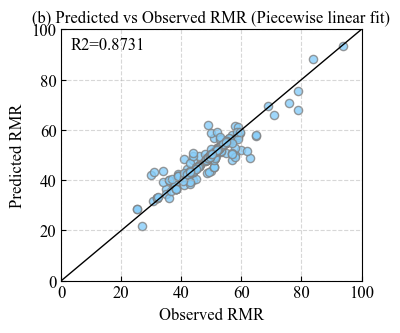

In [34]:
parity_plot(
    y=data["RMR"],
    yhat=pred_piece,
    title="(b) Predicted vs Observed RMR (Piecewise linear fit)"
)